# Simulation Study - Classification

In [855]:
### IMPORTS
# Core data manipulation and numerical computing libraries.
import pandas as pd
import numpy as np

# Plotting utilities used throughout the exploratory and final-fit plots.
import matplotlib.pyplot as plt
from IPython.display import display
plt.style.use('default')

# Sklearn models.
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

# Model-assessment metric used for every method comparison.
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Resampling utilities for train/test splits, k-fold CV, LOOCV, and CV predictions.
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score

# Pipeline helper lets preprocessing steps and regression models act as one estimator.
from sklearn.pipeline import make_pipeline

# Feature constructors used for nonlinear regression models.
from sklearn.preprocessing import StandardScaler


from sklearn.datasets import make_classification
from sklearn.datasets import make_moons


In [856]:
### GLOBAL VARS
# A single seed keeps every random split and simulated data set reproducible.
RANDOM_SEED = 123


## Data Generation

In [857]:
# Function to generate a simple linear dataset for binary classification
# First 2 feature contain real signal
# Remaining features are just random noise

def make_linear_data(n=100, separation=3.0, sigma=1.0, seed=None):

    # Randomly assign each sample to class 0 or 1
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n)

    X = np.zeros((n, 2))
    # Setting mean of each class
    class_means = np.array([[0.0, 0.0], [separation, separation]])

     # Generate data for each class separately
    for cls in [0, 1]:
        idx = np.where(y == cls)[0]

        # Sample values from a Gaussian dist centered at the class mean
        X[idx] = rng.normal(
            loc=class_means[cls],
            scale=sigma,
            size=(len(idx), 2)
        )

    # Keep separate modeling objects plus a dataframe version for plotting.
    columns = [f"x{i}" for i in range(1, X.shape[1] + 1)]
    data = pd.DataFrame(X, columns=columns)
    data["y"] = y

    return data


In [858]:
# Function for generating more compelx nonlinear data.
# Class 0 - single Gaussian centered at (0, 0)
# Class 1 - mixture of two Gaussians to create a nonlinear boundary
# Extra features are random noise

def make_non_linear_data(n=100, separation=3.0, sigma=0.9, seed=None):

    # Randomly assign each sample to class 0 or 1
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n)

    X = np.zeros((n, 2))

    # Class 0 - single Gaussian
    idx0 = np.where(y == 0)[0]
    # Generate points centered at (0, 0)
    X[idx0] = rng.normal(
        loc=[0.0, 0.0],
        scale=sigma,
        size=(len(idx0), 2)
    )

    # Class 1 - mixture of two Gaussians
    idx1 = np.where(y == 1)[0]
    component = rng.integers(0, 2, size=len(idx1))
    # Two cluster centers - left and right
    mixture_means = np.array([[-separation, 0.0], [separation, 0.0]])
    X[idx1] = rng.normal(
        loc=mixture_means[component],
        scale=sigma,
        size=(len(idx1), 2)
    )

    # Keep separate modeling objects plus a dataframe version for plotting.
    columns = [f"x{i}" for i in range(1, X.shape[1] + 1)]
    data = pd.DataFrame(X, columns=columns)
    data["y"] = y

    return data


In [859]:
# Visualizing one dataset from each base scenario.
scenarios = {
    "Easy Linear": [make_linear_data, {"separation": 3.0, "sigma": 1.0}],
    "Hard Linear": [make_linear_data, {"separation": 1.6, "sigma": 1.5}],
    "Easy Nonlinear": [make_non_linear_data, {"separation": 3.2, "sigma": 0.8}],
    "Hard Nonlinear": [make_non_linear_data, {"separation": 2.0, "sigma": 1.2}],
}

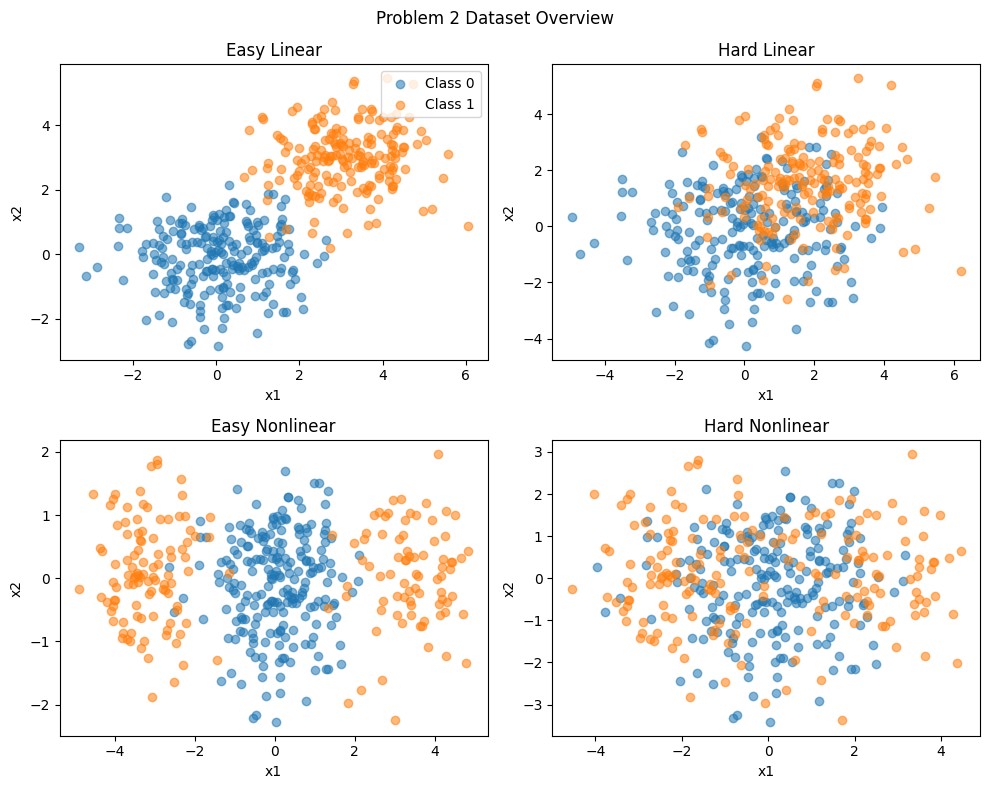

In [860]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, (generator, kwargs)) in zip(axes, scenarios.items()):
    data_plot = generator(n=400, seed=RANDOM_SEED, **kwargs)
    mask0 = data_plot["y"] == 0
    mask1 = data_plot["y"] == 1

    ax.scatter(data_plot.loc[mask0, "x1"], data_plot.loc[mask0, "x2"], alpha=0.55, label="Class 0")
    ax.scatter(data_plot.loc[mask1, "x1"], data_plot.loc[mask1, "x2"], alpha=0.55, label="Class 1")
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

axes[0].legend(loc="upper right")
plt.suptitle("Problem 2 Dataset Overview")
plt.tight_layout()
plt.show()


## Fit Functions

In [861]:
test_data = make_linear_data(100, seed=RANDOM_SEED)

### Logistic Regression

In [862]:
def fit_log_reg(data, cv_type, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression()
    )
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [863]:
acc, cm, rep = fit_log_reg(test_data, "kfold")
print(acc)
print(cm)
print(rep)

0.98
[[55  0]
 [ 2 43]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.96      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



### Linear Discriminant Analysis (LDA)

In [864]:
def fit_lda(data, cv_type, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis()
    )
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [865]:
acc, cm, rep = fit_lda(test_data, "kfold")
print(acc)
print(cm)
print(rep)

0.98
[[55  0]
 [ 2 43]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.96      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



### Quadratic Discriminant Analysis (QDA)

In [866]:
def fit_qda(data, cv_type, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = make_pipeline(
        StandardScaler(),
        QuadraticDiscriminantAnalysis()
    )
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [867]:
acc, cm, rep = fit_qda(test_data, "kfold")
print(acc)
print(cm)
print(rep)

0.98
[[55  0]
 [ 2 43]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.96      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



### K-Nearest Neighbors (KNN)

In [868]:
def fit_knn(data, cv_type, n=5, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=n)
    )
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [869]:
acc, cm, rep = fit_knn(test_data, "kfold", n = 5)
print(acc)
print(cm)
print(rep)

0.96
[[54  1]
 [ 3 42]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.98      0.93      0.95        45

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



### Decision Trees w Pruning

In [870]:
def fit_tree(data, cv_type, cpp=0, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = DecisionTreeClassifier(random_state=seed, ccp_alpha=cpp)
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [871]:
### No prunning
acc, cm, rep = fit_tree(test_data, "kfold", cpp = 0)
print(acc)
print(cm)
print(rep)

0.97
[[53  2]
 [ 1 44]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        55
           1       0.96      0.98      0.97        45

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [872]:
### Slightly pruned
acc, cm, rep = fit_tree(test_data, "kfold", cpp = 0.05)
print(acc)
print(cm)
print(rep)

0.96
[[53  2]
 [ 2 43]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.96      0.96      0.96        45

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



### Random Forests

In [873]:
def fit_rand_forest(data, cv_type, num_trees, max_feat = 2, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = RandomForestClassifier(random_state=seed, n_estimators=num_trees, max_features=max_feat)
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [874]:
acc, cm, rep =  fit_rand_forest(test_data, "kfold", num_trees=50)
print(acc)
print(cm)
print(rep)

0.98
[[54  1]
 [ 1 44]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        55
           1       0.98      0.98      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



### AdaBoostClassifier

In [875]:
def fit_ada_boost(data, cv_type, num_trees, max_depth = 1, lr = 1.0, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=max_depth),
        n_estimators=num_trees,
        learning_rate=lr,
        random_state=seed
    )
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [876]:
acc, cm, rep =  fit_rand_forest(test_data, "kfold", num_trees=50)
print(acc)
print(cm)
print(rep)

0.98
[[54  1]
 [ 1 44]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        55
           1       0.98      0.98      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



### Support Vector Machines (SVM)

In [877]:
def fit_svm(data, cv_type, C=1.0, k=5, seed=RANDOM_SEED):

    X = data[["x1", "x2"]]
    y = data["y"]

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'tts', 'kfold', or 'loo'")
    
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C)
    )
    cv_preds = cross_val_predict(model, X, y, cv=cv)
    
    acc = accuracy_score(y, cv_preds)
    cm = confusion_matrix(y, cv_preds)
    rep = classification_report(y, cv_preds)
    
    return acc, cm, rep

In [878]:
acc, cm, rep =  fit_svm(test_data, "kfold", C=1)
print(acc)
print(cm)
print(rep)

0.98
[[55  0]
 [ 2 43]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.96      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



## Simulation Test Function

In [879]:
for scen in scenarios.items():
    print(scen)

('Easy Linear', [<function make_linear_data at 0x134627740>, {'separation': 3.0, 'sigma': 1.0}])
('Hard Linear', [<function make_linear_data at 0x134627740>, {'separation': 1.6, 'sigma': 1.5}])
('Easy Nonlinear', [<function make_non_linear_data at 0x134627600>, {'separation': 3.2, 'sigma': 0.8}])
('Hard Nonlinear', [<function make_non_linear_data at 0x134627600>, {'separation': 2.0, 'sigma': 1.2}])


In [886]:
def sim_test_cv(scenario, reps=10):
    
    scen_name = scenario[0]
    data_gen_func = scenario[1][0]
    data_kwargs = scenario[1][1]

    print(scen_name, "->", data_gen_func, "->", data_kwargs)

    res_dict = {}
    ccp_alphas = np.linspace(0, 0.25, 100)
    for ccp in ccp_alphas:
        res_dict[ccp] = []

    for rep in range(0, reps):
        data = data_gen_func(**data_kwargs, seed=rep)
    
        for cpp in ccp_alphas:
            acc, cm, rep = fit_tree(data, cv_type="kfold", cpp=cpp)
            res_dict[cpp].append(acc)

    rows = []
    for cpp, acc_list in res_dict.items():
        rows.append({"cpp": float(cpp), "mean_acc": float(np.average(acc_list))})

    df = pd.DataFrame(rows)

    return res_dict, df


In [887]:
res_dict, df = sim_test_cv(next(iter(scenarios.items())), reps=5)

Easy Linear -> <function make_linear_data at 0x134627740> -> {'separation': 3.0, 'sigma': 1.0}


In [889]:
df = df.sort_values(by="mean_acc", ascending=False)

In [ ]:
df

,cpp,mean_acc
0,0.000000,0.958
2,0.005051,0.958
3,0.007576,0.958
4,0.010101,0.958
1,0.002525,0.958
...,...,...
69,0.174242,0.920
70,0.176768,0.920
71,0.179293,0.920
72,0.181818,0.920


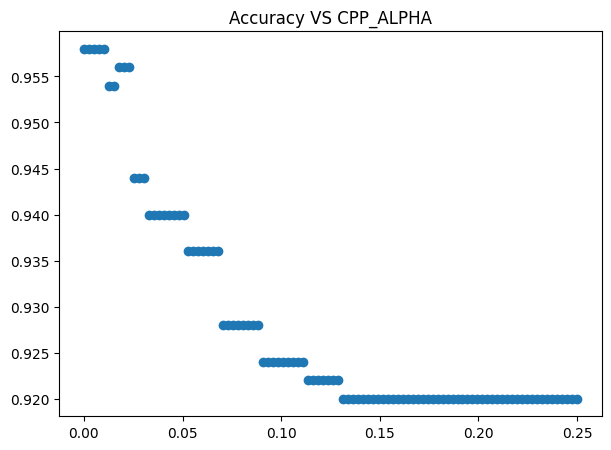

In [892]:
plt.figure(figsize=(7,5))

plt.scatter(df["cpp"], df["mean_acc"])
plt.title("Accuracy VS CPP_ALPHA")
plt.show()